[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ferit-osirv/lab8/blob/main/lab8.ipynb)

# FERIT AI workshop

**This command must be run before starting to do each lab.**

In [2]:
!rm -rf clone && git clone https://github.com/ferit-osirv/lab8 clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 8.79 KiB | 8.79 MiB/s, done.
Resolving deltas: 100% (2/2), done.
cp: ././.git/objects/pack/pack-1961707fbcce77ec7a1acace2bc483396e5e1cde.pack: Permission denied
cp: ././.git/objects/pack/pack-1961707fbcce77ec7a1acace2bc483396e5e1cde.idx: Permission denied


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import utils
import torch
import torch.nn as nn
import torch.optim as optim
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torchvision
import torchvision.transforms as transforms

torch.manual_seed(1)

/Users/marinbenc/miniconda3/envs/tutorial/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
X, labels = utils.train_dataset_grades(1000)
print(X, labels)

tensor([[7.5763, 2.5818, 4.0735],
        [2.7931, 1.4637, 5.1654],
        [4.0307, 1.7652, 7.9580],
        ...,
        [0.7175, 3.7375, 8.8844],
        [3.4247, 2.0647, 7.2998],
        [7.1859, 1.9683, 1.8416]]) tensor([1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0.,
        1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1.,
        1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1.,
        0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1.,
        1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.

Definiranje modela

           x1=broj_sati --- w1=0.8 ---\\
                                       >--- (N1_in) -> ReLU -> N1_out
           x2=prosjek  --- w2=0.2 ---/
                                       \\
           x3=izostanci - w3=-0.5 ----/  + b1=0.1


           x1=broj_sati --- w4=0.1 ---\\
                                       >--- (N2_in) -> ReLU -> N2_out
           x2=prosjek  --- w5=0.8 ---/
                                       \\
           x3=izostanci - w6=-0.2 ----/  + b2=0.05


                                N1_out -- w7=1.0 --\\
                                                   >--- (y_in) --> y_out
                                N2_out -- w8=0.5 --/
                                                   + b3=-0.2

In [5]:
X, labels = utils.train_dataset_grades(1000)
X_test, labels_test = utils.test_dataset_grades(100)

# 2. Definiraj mrežu
# -------------------
# Input: 3 -> Skriveni sloj (2 neurona, ReLU) -> Izlaz: 1
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(3, 2)   # 3 ulaza -> 2 neurona
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(2, 1)  # 2 -> 1 izlaz

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNet()

# 3. Definiraj gubitak i optimizer
# ---------------------------------
criterion = nn.BCEWithLogitsLoss()  # Binary Cross Entropy za binarnu klasifikaciju
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 4. Trening petlja
# -----------------
num_epochs = 500

for epoch in range(num_epochs):
    # Forward
    outputs = model(X)
    loss = criterion(outputs.squeeze(), labels)  # squeeze da se shape poklopi (N) vs (N,1)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # (Povremeni ispis)
    if (epoch+1) % 100 == 0:
        with torch.no_grad():
            predicted = (outputs.squeeze() >= 0.5).float()
            accuracy = (predicted == labels).float().mean()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy.item():.4f}")

# 5. Testiranje na istim podacima (jer su fejk, nemamo odvojeni skup)
with torch.no_grad():
    outputs = model(X_test).squeeze()
    predicted = (outputs >= 0.5).float()
    accuracy = (predicted == labels_test).float().mean()
    print(f"Final Accuracy on training data: {accuracy.item():.4f}")

Epoch [100/500], Loss: 0.4885, Accuracy: 0.7770
Epoch [200/500], Loss: 0.3568, Accuracy: 0.9020
Epoch [300/500], Loss: 0.2872, Accuracy: 0.9340
Epoch [400/500], Loss: 0.2534, Accuracy: 0.9530
Epoch [500/500], Loss: 0.2311, Accuracy: 0.9600
Final Accuracy on training data: 0.9400


In [6]:
# Isprobavanje modela

hours_studied = 2
grade = 5
absences = 10

input = torch.tensor([hours_studied, grade, absences], dtype=torch.float32)
output = model(input).item()
print(f"Model output for input {input.numpy()}: {output:.4f}")

Model output for input [ 2.  5. 10.]: -0.2342


samostalan rad: Neka stvore nekoliko slučajeva

1. Student koji malo uči ali je imao dobar prosjek
2. Student koji puno uči i ima dobar prosjek

Neka vide kako se razlikuje njihov vjerojatnost da budu dobri

## MNIST

In [7]:
train_dataset = utils.get_mnist_dataset_train()
test_dataset = utils.get_mnist_dataset_test()

# train_dataset[0] je tuple (slika, label)
# train_dataset[0][0] je slika
# train_dataset[0][1] je label

0


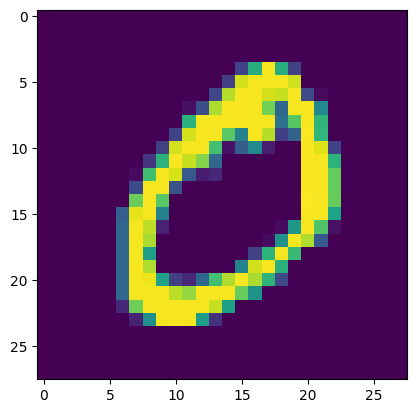

In [8]:
img, label = train_dataset[1]
plt.imshow(img.squeeze())
print(label)

In [9]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)

# prije smo imali
#for image, label in dataset:
#    output = model(image)

# sad imamo

for images, labels in train_loader:
    print(images.shape, labels.shape)
    # output = model(images) # model prima batch od 64 slike 64 x 1 x 28 x 28
    break

# radimo 64 po 64 slike, umjesto jednu po jednu

torch.Size([64, 1, 28, 28]) torch.Size([64])


samostalan rad: ali nek sami definiraju model - to je zadatak

Input su svi pikseli slike (32 x 32) a output je 10 klasa (0, 1, …)
Neka prvi sloj ide od 784 do 256 s ReLU izlazom
Neka drugi sloj ide od 256 do 10

In [10]:
class FullyConnectedMNIST(nn.Module):
    def __init__(self):
        super(FullyConnectedMNIST, self).__init__()
        # ... tu oni definiraju

    def forward(self, x):
        # x dimenzije: (batch_size, 1, 28, 28)
        # moramo spljoštiti u (batch_size, 784)
        x = x.view(x.size(0), -1)  # flatten
        # x dimenzije: (batch_size, 784)
        
        # ... tu oni definiraju
        return x

In [11]:
# 2. Definiraj potpuno povezanu mrežu
# ------------------------------------
# Ulaz je veličine 28*28 = 784
# Izlaz je 10 klasa (znamenke 0-9)
class FullyConnectedMNIST(nn.Module):
    def __init__(self):
        super(FullyConnectedMNIST, self).__init__()
        self.fc1 = nn.Linear(784, 256)  # prvi sloj
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)   # izlazni sloj, 10 klasa

    def forward(self, x):
        # x dimenzije: (batch_size, 1, 28, 28)
        # moramo spljoštiti u (batch_size, 784)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

sad idemo trenirati

In [12]:
model = FullyConnectedMNIST()

# 3. Definiraj gubitak i optimizer
# --------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 4. Trening petlja
# -----------------
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    correct_predictions = 0
    total_predictions = 0
    for images, labels in train_loader:
        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Racunanje tocnosti
        total_predictions += len(labels)
        predicted = outputs.argmax(dim=1)
        correct_predictions += (predicted == labels).sum().item()

    accuracy = correct_predictions / total_predictions
    print(f"Epoch [{epoch+1}/{num_epochs}], Accuracy: {accuracy:.4f}")

Epoch [1/5], Accuracy: 0.7458
Epoch [2/5], Accuracy: 0.8759
Epoch [3/5], Accuracy: 0.8924
Epoch [4/5], Accuracy: 0.9014
Epoch [5/5], Accuracy: 0.9077


testiranje

tensor(7)


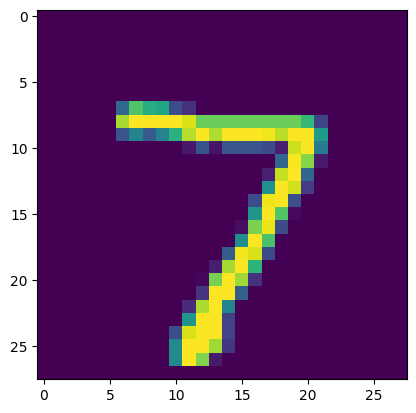

In [13]:
test_data = utils.get_mnist_dataset_test()

img, label = test_data[0]
plt.imshow(img.squeeze())

output = model(img.unsqueeze(0))
predicted = output.argmax()

print(predicted)

u stvarnosti bi sad racunali accuracy i to na testnom skupu

## CNN MNIST

Uvod u CNN-ove **TODO** Raspiši

In [14]:
class CNNMnist(nn.Module):
    def __init__(self):
        super(CNNMnist, self).__init__()
        # Dva konvolucijska sloja + pooling za smanjenje dimenzija
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)  # prepolovi visinu i širinu

        # Nakon dvostrukog poolinga (28 -> 14 -> 7), ostaje 7x7, sa 32 kanala
        self.fc1 = nn.Linear(32 * 7 * 7, 128)  # potpuno povezani sloj
        self.fc2 = nn.Linear(128, 10)          # završni sloj, 10 klasa

    def forward(self, x):
        # x: (batch_size, 1, 28, 28)
        x = F.relu(self.conv1(x))  # -> (batch_size, 16, 28, 28)
        x = self.pool(x)           # -> (batch_size, 16, 14, 14)
        x = F.relu(self.conv2(x))  # -> (batch_size, 32, 14, 14)
        x = self.pool(x)           # -> (batch_size, 32, 7, 7)
        
        # Spljoštimo (batch_size, 32*7*7)
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))    # -> (batch_size, 128)
        x = self.fc2(x)            # -> (batch_size, 10) (logits za svaku od 10 znamenki)
        
        return x

In [15]:
model = CNNMnist()

data_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=256, 
    shuffle=True
)

# 3. Definiraj gubitak i optimizer
# --------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 4. Trening petlja
# -----------------
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    correct_predictions = 0
    total_predictions = 0
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Racunanje tocnosti
        total_predictions += len(labels)
        predicted = outputs.argmax(dim=1)
        correct_predictions += (predicted == labels).sum().item()

    accuracy = correct_predictions / total_predictions
    print(f"Epoch [{epoch+1}/{num_epochs}], Accuracy: {accuracy:.4f}")

KeyboardInterrupt: 

## Dataset i segmentacija

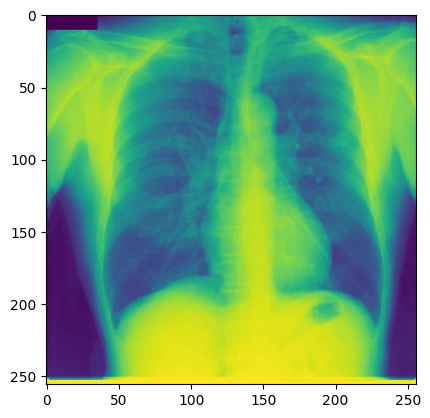

In [16]:
# Primjer putanja do jedne X-ray slike i njene maske (prilagodite svojim direktorijima)
image_path = "data/images/JPCLN001.jpg"
label_path = "data/labels/JPCLN001.png"

# Učitaj sliku (konverzija u grayscale)
xray_image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
xray_label = cv.imread(label_path, cv.IMREAD_GRAYSCALE)

plt.imshow(xray_image)

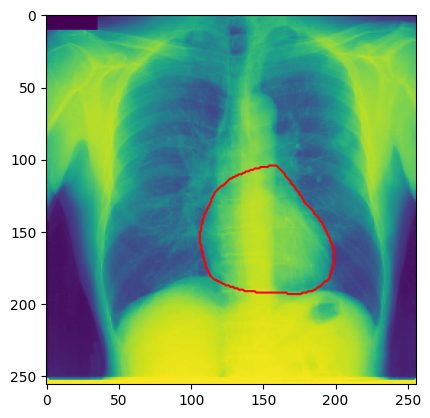

In [17]:
plt.imshow(xray_image)
plt.contour(xray_label, levels=[0.5], colors='r')

## Što je segmentacija?

- Za razliku od **klasifikacije** (npr. “slika srca ili nije”), segmentacija pokušava svakom pikselu slike pridružiti pripadnost određenoj klasi.
- U **binarnoj segmentaciji** (kao ovdje), svaki piksel je ili “dio interesne regije” (1) ili “pozadina” (0). U našem slučaju, regija interesa je srce na X-ray slici.

---

### 2. PyTorch `Dataset` za binarnu segmentaciju (X-ray + srce maska)

Slijedi kod za prilagođeni `Dataset` koji:

- U **init** metodi dohvaća sve putanje do slika i maski.
- U **getitem** učitava sliku i pripadajuću masku, normalizira sliku, binarizira masku i vraća sve kao PyTorch tenzore.

### Directory struktura (primjer)

```
dataset/
  images/
    image1.jpg
    image2.jpg
    ...
  labels/
    label1.png
    label2.png
    ...

```

Pretpostavljamo da `image1.jpg` odgovara `label1.png`, `image2.jpg` -> `label2.png`, itd

In [24]:
class XRayHeartDataset(Dataset):
    def __init__(self):
        """
        root_dir: direktorij s 'images' i 'labels' poddirektorijima
        transform: (opcionalno) primijeni transformacije na slike
        """
        images_dir = 'data/images'
        labels_dir = 'data/labels'

        self.image_paths = utils.get_image_files_in_folder(images_dir)
        self.label_paths = utils.get_image_files_in_folder(labels_dir)

    def __len__(self):
        return 64
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        lbl_path = self.label_paths[idx]

        image = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
        label = cv.imread(lbl_path, cv.IMREAD_GRAYSCALE)

        label = np.where(label > 128, 1, 0)
        
        # normalize
        image = image / 255.0

        image_np = np.expand_dims(image, axis=0)
        label = np.expand_dims(label, axis=0)

        image_tensor = torch.from_numpy(image_np).float()
        label_tensor = torch.from_numpy(label).float()

        return image_tensor, label_tensor

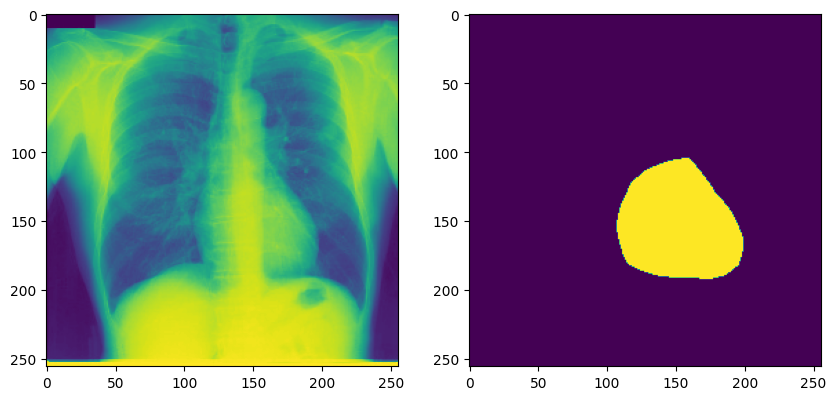

In [25]:
dataset = XRayHeartDataset()

image, label = dataset[0]

# Prikaz prvih 2 slike iz batcha
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image.squeeze())
plt.subplot(122)
plt.imshow(label.squeeze())

## Što je FCN?

- **FCN (Fully Convolutional Network)** je mreža u kojoj se sve operacije baziraju na konvolucijama (i eventualno transponiranim konvolucijama za “upsampling”), bez klasičnih potpuno povezanih slojeva pri kraju.
- Za segmentaciju, uobičajeni pristup je:
    1. **Downsampling** kroz konvolucijske i pooling slojeve (poput klasičnog CNN-a) — hvata se širi “kontekst”.
    2. **Upsampling** (npr. transponirana konvolucija, “bilinear upsample” i sl.) kako bismo vratili izlaz na originalnu rezoluciju. Svaki piksel dobije klasnu oznaku.

U **binarnoj** segmentaciji (kao kod srca naspram pozadine), izlaz FCN-a obično ima **1 kanal** (umjesto 2 kanala za background i foreground). Taj 1 kanal odgovara “logit-u” koji može kasnije proći kroz sigmoid.

### Pojednostavljeni dijagram:

```
scss
CopyEdit
Ulazna slika (1, H, W)
  --> [Conv -> ReLU -> Pool] x N puta  (downsampling)
  --> [Conv 1x1] (mapiranje na željeni broj kanala, npr. 1)
  --> [Upsample / Transposed Conv] (vraćanje na originalnu dimenziju)
  --> [Sigmoid] (svaki piksel -> [0..1])

```

```
   (N, 1, H, W)
       |
   [Conv2d -> ReLU]
       |
   [MaxPool2d (2x2)]
       |
   [Conv2d -> ReLU]
       |
   [Conv2d 1x1 -> (feature map dim = 1)]
       |
   [Upsample/TransposedConv -> (H, W)]
       |
   [Sigmoid]
       |
   (N, 1, H, W)  # binarna maska```

In [26]:
class SimpleFCN(nn.Module):
    def __init__(self):
        super(SimpleFCN, self).__init__()

        # Downsampling
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)  # prepolovljava H i W

        # Bottleneck 1x1 conv (možeš i klasične conv)
        self.conv_bottleneck = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=1)

        # 1x1 conv koji će nam dati "logit" za 1 klasu (foreground)
        self.classifier = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=1)

        # Up-sampling (transponirana konvolucija) - vraća na originalnu vel.
        self.up = nn.ConvTranspose2d(in_channels=1, out_channels=1,
                                     kernel_size=2, stride=2)

    def forward(self, x):
        # x: (N, 1, H, W)
        # Down
        x = F.relu(self.conv1(x))   # (N, 8, H, W)
        x = self.pool(x)           # (N, 8, H/2, W/2)
        x = F.relu(self.conv2(x))  # (N, 16, H/2, W/2)
        x = self.pool(x)           # (N, 16, H/4, W/4)
        x = F.relu(self.conv3(x))
        x = self.pool(x)           # (N, 32, H/8, W/8)

        # Bottleneck
        x = F.relu(self.conv_bottleneck(x))  # (N,16,H/4,W/4)

        # 1x1 conv (mapa za 1 klasu)
        x = self.classifier(x)     # (N, 1, H/4, W/4)

        # Up
        x = self.up(x)             # (N, 1, H/2, W/2)
        x = self.up(x)             # (N, 1, H,   W)
        x = self.up(x)

        # Binarna segmentacija -> Sigmoid
        x = torch.sigmoid(x)       # (N, 1, H, W)  -> [0..1]

        return x

In [31]:
!pip install segmentation-models-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 11.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 464.1/464.1 kB 10.7 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.9/408.9 kB 10.3 MB/s eta 0:00:0000:01
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16429 sha256=bfd26c62b4712423dbd354bd89f9d92017cfd15c08b3e18fd13606e8f0b2176b
  Stored in directory: /Users/marinbenc/Library/Caches/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=913

Ova mreža radi dvostruko poolinganje, pa zatim dvaput upsampla (svaki ConvTranspose2d s kernel_size=2, stride=2 udvostručuje prostorne dimenzije). Rezultat je da na kraju ponovo dobijemo (H, W). Možete i skratiti, ovisno o željenoj složenosti.

**todo** najbolje je da im dam checkpoint treniranog modela

In [ ]:
# 2. Inicijaliziraj FCN model
import segmentation_models_pytorch as smp

model = smp.Unet('mobilenet_v2', in_channels=1, classes=1)

# 3. Definiraj optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# 4. Trening petlja
num_epochs = 100

dataset = XRayHeartDataset()
train_loader = DataLoader(dataset, batch_size=256, shuffle=True)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for images, labels in train_loader:
        # images shape: (N, 1, H, W)
        # labels shape: (N, 1, H, W)

        optimizer.zero_grad()
        outputs = model(images)  # (N, 1, H, W) -> nakon sigmoid
        loss = utils.dice_loss(outputs, labels).mean()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/marinbenc/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:01<00:00, 11.5MB/s]


Epoch [1/100], Loss: 0.7782
Epoch [2/100], Loss: 0.1597


KeyboardInterrupt: 